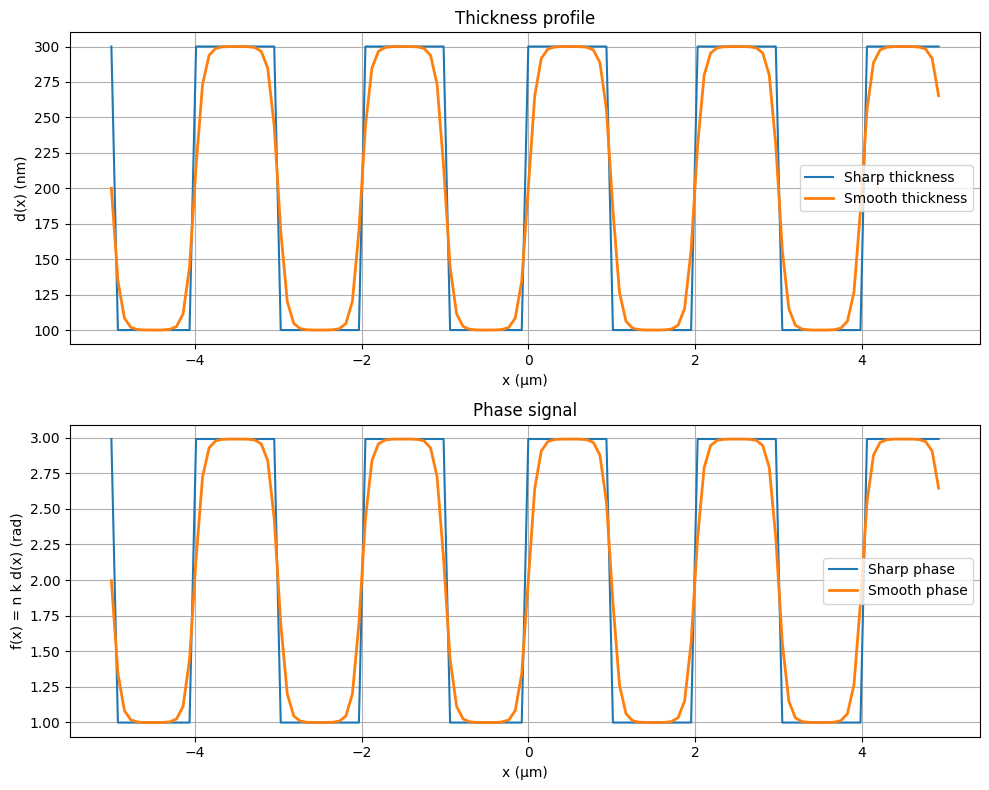

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def smooth_step(z, k):
    return 0.5 * (1 + np.tanh(k * z))

def thickness_profile_sharp(x, Lambda, duty, d0, h):
    phase = (x % Lambda) / Lambda
    return d0 + h * (phase < duty).astype(float)

def thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=40):
    """
    Periodic smooth rectangular profile.
    
    phase in [0,1)
    high region: 0 <= phase < duty
    smooth transitions at phase = 0 and phase = duty
    """
    phase = (x % Lambda) / Lambda

    # periodic distance from the center of the high region
    center = duty / 2
    u = phase - center
    u = (u + 0.5) % 1.0 - 0.5   # wrap to [-0.5, 0.5)

    halfwidth = duty / 2

    # smooth top-hat
    pulse = 0.5 * (1 - np.tanh(k * (np.abs(u) - halfwidth)))

    return d0 + h * pulse

def phase_signal(d, n, lam):
    k0 = 2 * np.pi / lam
    return n * k0 * d

def plot_profiles(x, d_sharp, d_smooth, f_sharp, f_smooth):
    plt.figure(figsize=(10, 8))

    plt.subplot(2, 1, 1)
    plt.plot(x * 1e6, d_sharp * 1e9, label="Sharp thickness", linewidth=1.5)
    plt.plot(x * 1e6, d_smooth * 1e9, label="Smooth thickness", linewidth=2)
    plt.xlabel("x (µm)")
    plt.ylabel("d(x) (nm)")
    plt.title("Thickness profile")
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(x * 1e6, f_sharp, label="Sharp phase", linewidth=1.5)
    plt.plot(x * 1e6, f_smooth, label="Smooth phase", linewidth=2)
    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title("Phase signal")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

# -----------------------------
# Parameters
# -----------------------------
L = 10e-6
Nx = 128

lam = 630e-9
n = 1.0

Lambda = 2e-6
duty = 0.50
d0 = 100e-9
h = 200e-9

smoothness_k = 20   # increase for sharper edges

# -----------------------------
# Build profiles
# -----------------------------
x = spatial_grid(L, Nx)

d_sharp = thickness_profile_sharp(x, Lambda, duty, d0, h)
d_smooth = thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=smoothness_k)

f_sharp = phase_signal(d_sharp, n, lam)
f_smooth = phase_signal(d_smooth, n, lam)

# -----------------------------
# Plot
# -----------------------------
plot_profiles(x, d_sharp, d_smooth, f_sharp, f_smooth)

In [8]:
import numpy as np

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha

In [9]:
# compute phi for smoothed signal
phi_smooth, alpha_smooth = phi_from_f(f_smooth)

print("alpha (smooth) =", alpha_smooth)
print("check normalization =", np.sum(phi_smooth**2))
print("phi (smooth) =", phi_smooth)

alpha (smooth) = 255.31673629174188
check normalization = 1.0
phi (smooth) = [0.08838835 0.0725263  0.06507734 0.06306777 0.06262031 0.06252527
 0.0625053  0.06250724 0.06253454 0.06266426 0.06327221 0.06594579
 0.0751405  0.09174929 0.10334393 0.10712347 0.1080114  0.10820227
 0.1082425  0.10825094 0.10824746 0.10822591 0.10812342 0.10764108
 0.10548037 0.09757186 0.08142506 0.06851543 0.06391996 0.06280584
 0.06256448 0.06251353 0.06250284 0.06251353 0.06256448 0.06280584
 0.06391996 0.06851543 0.08142506 0.09757186 0.10548037 0.10764108
 0.10812342 0.10822591 0.10824746 0.10825094 0.1082425  0.10820227
 0.1080114  0.10712347 0.10334393 0.09174929 0.0751405  0.06594579
 0.06327221 0.06266426 0.06253454 0.06250724 0.0625053  0.06252527
 0.06262031 0.06306777 0.06507734 0.0725263  0.08838835 0.10180833
 0.10672366 0.10792338 0.10818363 0.10823858 0.10825012 0.10824899
 0.10823323 0.10815817 0.10780365 0.10618923 0.09989447 0.08489445
 0.07032093 0.06441709 0.06291691 0.06258809 0.06251

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
from qiskit.quantum_info import state_fidelity


# ----------------------------
# Functions (make sure these exist)
# ----------------------------
def spatial_grid(L, Nx):
    return np.linspace(-L/2, L/2, Nx, endpoint=False)

def thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=30):
    phase = (x % Lambda) / Lambda

    center = duty / 2
    u = phase - center
    u = (u + 0.5) % 1.0 - 0.5

    halfwidth = duty / 2
    pulse = 0.5 * (1 - np.tanh(k * (np.abs(u) - halfwidth)))

    return d0 + h * pulse

def phase_signal(d, n_refr, lam):
    k0 = 2 * np.pi / lam
    return n_refr * k0 * d

def phi_from_f(f):
    alpha = np.sum(f)
    phi = np.sqrt(f / alpha)
    return phi, alpha


# ----------------------------
# Parameters
# ----------------------------
sim = AerSimulator(method="statevector")

qubit_range = range(6, 11)
layer_range = range(50, 701, 50)

# physical params (make sure defined)
T = 10e-6
Lambda = 2e-6
duty = 0.50
d0 = 100e-9
h = 200e-9
lam = 630e-9
n_refr = 1.0

smoothness_k = 30  # <-- control smoothing

# fidelity storage
fidelity_map_smooth = np.zeros((len(layer_range), len(qubit_range)))


# ----------------------------
# Main loop
# ----------------------------
for qi, n_qubits in enumerate(qubit_range):

    Nx = 2**n_qubits

    # --- smooth profile ---
    x = spatial_grid(T, Nx)
    d_smooth = thickness_profile_smooth_periodic(
        x, Lambda, duty, d0, h, k=smoothness_k
    )

    f_smooth = phase_signal(d_smooth, n_refr, lam)
    phi_smooth, _ = phi_from_f(f_smooth)

    phi_smooth = np.asarray(phi_smooth, dtype=complex)
    phi_smooth = phi_smooth / np.linalg.norm(phi_smooth)

    print(f"\nRunning (SMOOTH) for {n_qubits} qubits")

    for li, L in enumerate(layer_range):

        phi_state = QuantumState.from_dense_data(
            data=phi_smooth, normalize=False
        )
        U_phi = phi_state.generate_mps_initializer_circuit(
            number_of_layers=L
        )

        qc = QuantumCircuit(n_qubits)
        qc.append(U_phi, range(n_qubits))
        qc.save_statevector()

        result = sim.run(transpile(qc, sim)).result()
        vec_sim = np.array(result.get_statevector(qc), dtype=complex)

        F = state_fidelity(vec_sim, phi_smooth)

        fidelity_map_smooth[li, qi] = F




Running (SMOOTH) for 6 qubits

Running (SMOOTH) for 7 qubits

Running (SMOOTH) for 8 qubits

Running (SMOOTH) for 9 qubits

Running (SMOOTH) for 10 qubits


In [12]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 0.99

best_layers_smooth = []
fidelities_at_threshold = []

for qi, n_qubits in enumerate(qubit_range):
    fidelities = fidelity_map_smooth[:, qi]

    idx = np.where(fidelities >= threshold)[0]

    if len(idx) > 0:
        first_idx = idx[0]
        chosen_layer = layer_range[first_idx]
        chosen_fidelity = fidelities[first_idx]
    else:
        chosen_layer = np.nan
        chosen_fidelity = np.nan

    best_layers_smooth.append(chosen_layer)
    fidelities_at_threshold.append(chosen_fidelity)

    print(f"[SMOOTH] Qubits = {n_qubits}, "
          f"Layer = {chosen_layer}, "
          f"Fidelity = {chosen_fidelity}")

[SMOOTH] Qubits = 6, Layer = 50, Fidelity = 0.9999999911909807
[SMOOTH] Qubits = 7, Layer = 150, Fidelity = 0.9999999998209166
[SMOOTH] Qubits = 8, Layer = 150, Fidelity = 0.999499302180447
[SMOOTH] Qubits = 9, Layer = 400, Fidelity = 0.9958872549261515
[SMOOTH] Qubits = 10, Layer = nan, Fidelity = nan


Used for fitting:
Qubits = 6, Layers = 50.0
Qubits = 7, Layers = 150.0
Qubits = 8, Layers = 150.0
Qubits = 9, Layers = 400.0

Fit quality:
Linear R² = 0.8242990654205608
Quadratic R² = 0.9084112149532709
Exponential R² = 0.9275196961366375


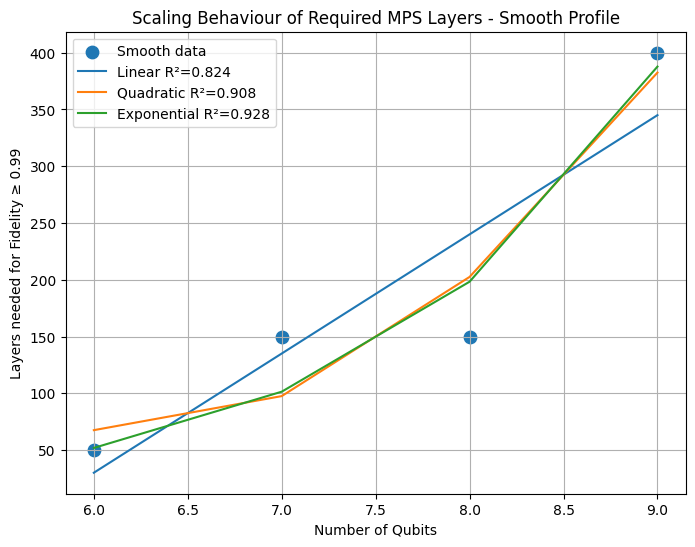

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

x = np.array(list(qubit_range), dtype=float)
y = np.array(best_layers_smooth, dtype=float)

# remove NaN values
mask = np.isfinite(y)

x_fit = x[mask]
y_fit = y[mask]

print("Used for fitting:")
for q, L in zip(x_fit, y_fit):
    print(f"Qubits = {int(q)}, Layers = {L}")

# Linear fit
linear_coeff = np.polyfit(x_fit, y_fit, 1)
linear_model = np.poly1d(linear_coeff)
y_linear = linear_model(x_fit)

# Quadratic fit
quad_coeff = np.polyfit(x_fit, y_fit, 2)
quad_model = np.poly1d(quad_coeff)
y_quad = quad_model(x_fit)

# Exponential fit
def exp_func(x, A, B):
    return A * np.exp(B * x)

params, _ = curve_fit(exp_func, x_fit, y_fit, maxfev=10000)
y_exp = exp_func(x_fit, *params)

# R² scores
r2_linear = r2_score(y_fit, y_linear)
r2_quad = r2_score(y_fit, y_quad)
r2_exp = r2_score(y_fit, y_exp)

print("\nFit quality:")
print("Linear R² =", r2_linear)
print("Quadratic R² =", r2_quad)
print("Exponential R² =", r2_exp)

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(x_fit, y_fit, s=80, label="Smooth data")

plt.plot(x_fit, y_linear, label=f"Linear R²={r2_linear:.3f}")
plt.plot(x_fit, y_quad, label=f"Quadratic R²={r2_quad:.3f}")
plt.plot(x_fit, y_exp, label=f"Exponential R²={r2_exp:.3f}")

plt.xlabel("Number of Qubits")
plt.ylabel(f"Layers needed for Fidelity ≥ {threshold}")
plt.title("Scaling Behaviour of Required MPS Layers - Smooth Profile")
plt.legend()
plt.grid(True)
plt.show()

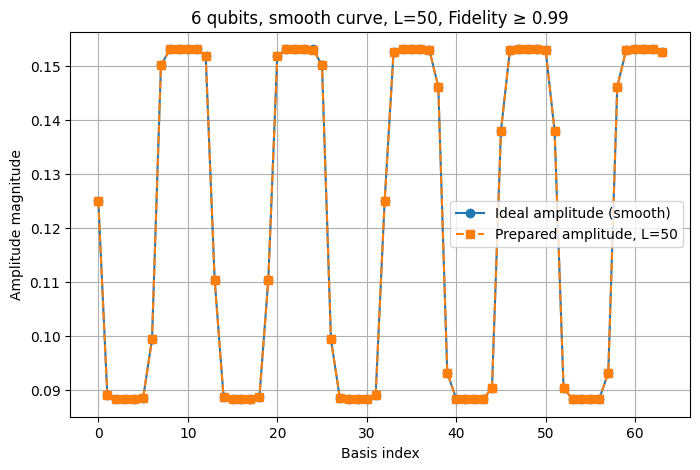

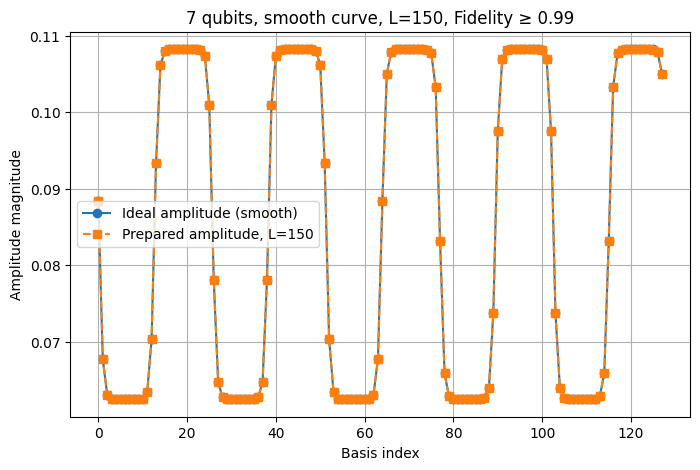

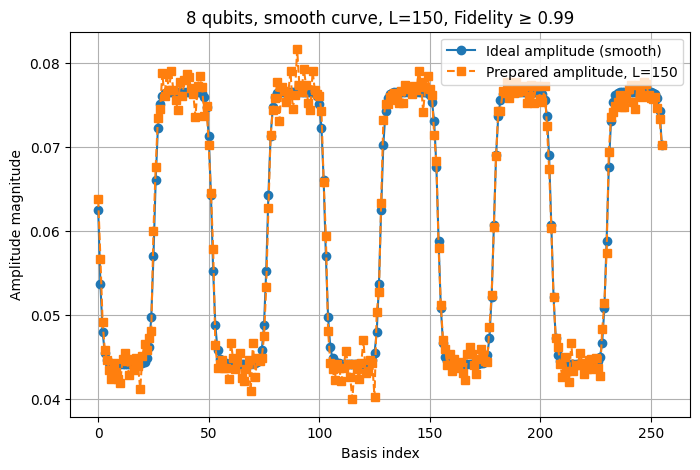

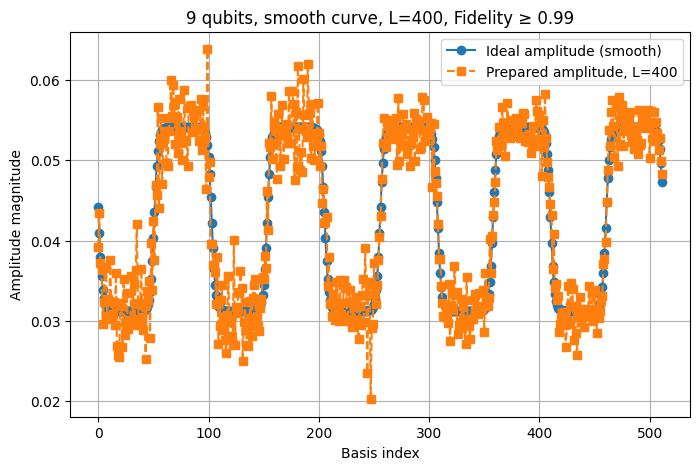

10 qubits: fidelity 0.99 not reached for smooth curve.


In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_mps_initializer.datatypes import QuantumState
import numpy as np
import matplotlib.pyplot as plt

sim = AerSimulator(method="statevector")

for qi, n_qubits in enumerate(qubit_range):
    chosen_layer = best_layers_smooth[qi]   # use smooth-layer list

    if np.isnan(chosen_layer):
        print(f"{n_qubits} qubits: fidelity {threshold} not reached for smooth curve.")
        continue

    Nx = 2**n_qubits

    # regenerate phi for this qubit count from SMOOTH profile
    x = spatial_grid(T, Nx)
    d_smooth = thickness_profile_smooth_periodic(x, Lambda, duty, d0, h, k=smoothness_k)
    f_smooth = phase_signal(d_smooth, n_refr, lam)
    phi_smooth, _ = phi_from_f(f_smooth)

    phi_smooth = np.asarray(phi_smooth, dtype=complex)
    phi_smooth = phi_smooth / np.linalg.norm(phi_smooth)

    # build threshold-layer circuit
    phi_state = QuantumState.from_dense_data(data=phi_smooth, normalize=False)
    U_phi = phi_state.generate_mps_initializer_circuit(number_of_layers=int(chosen_layer))

    qc = QuantumCircuit(n_qubits)
    qc.append(U_phi, range(n_qubits))
    qc.save_statevector()

    result = sim.run(transpile(qc, sim)).result()
    vec_sim = np.array(result.get_statevector(qc), dtype=complex)

    # align global phase
    global_phase = np.angle(np.vdot(phi_smooth, vec_sim))
    vec_sim_aligned = vec_sim * np.exp(-1j * global_phase)

    amps_ideal = np.abs(phi_smooth)
    amps_sim = np.abs(vec_sim_aligned)

    plt.figure(figsize=(8, 5))
    plt.plot(range(Nx), amps_ideal, 'o-', label="Ideal amplitude (smooth)")
    plt.plot(range(Nx), amps_sim, 's--', label=f"Prepared amplitude, L={int(chosen_layer)}")
    plt.xlabel("Basis index")
    plt.ylabel("Amplitude magnitude")
    plt.title(f"{n_qubits} qubits, smooth curve, L={int(chosen_layer)}, Fidelity ≥ {threshold}")
    plt.legend()
    plt.grid(True)
    plt.show()